## 1. Introduction
**The dataset:** World Happiness Report 2019 published by the United Nations Sustainable Development Solutions Network (SDSN). The dataset was downloaded from Kaggle: https://www.kaggle.com/datasets/unsdsn/world-happiness?select=2019.csv

**Data source:** The data comes from the gallup World Poll and was gathered through a survey where citizens from each country were randomly selected and asked to respond to selected questions.

**What is a row?**
Each row is one country. There is a total of 156 countries in the dataset.

**What the numeric columns mean:** The columns: GDP per capita, Social support, Healthy life expectancy, Freedom to make life choices, Generosity, and Perceptions of corruption are not the actual raw values. They represent each factor's contribution to the happiness score in a regression model. Eg, GDP is log(GDP/capita) adjusted for purchasing power parity (PPP).

**Key limitation:** This dataset shows correlations, not causation. The focus on a wealthier country being happier does not prove that wealth causes happiness especially with no consideration to different cultural view of "best life". 

In [83]:
#pip install seaborn

In [84]:
# Get needed Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Dataset loading and Mechanical inspection

In [ ]:
# Import/Read and inspect dataset
df = pd.read_csv("data/data-2019.csv")
print(f"Shape: {df.shape}")   # (156, 9)
print(f"Information: {df.info()}")    # data type and structure
print(f"Estimates:\n {df.describe()}")  # statistical overview

The ´.describe()´ output reveals several columns with a minimum value of 0.000. Looking at the Healthy life expectancy column, a 0 years would mean that people are born and immediately die. That does not seem to be correct. I guess, in all, the 0 represents a missing data and not actual measurements.

In [ ]:
# Change column name
df = df.rename(columns={'Country or region': 'Country'})
df.head()
# pd.set_option('display.max_row', None)  # Removes row limit
# df.head(len(df))  # Show all data

In [ ]:
# Investigate columns with 0 values of interest

columns_of_interest = ["Healthy life expectancy", "GDP per capita", "Social support"]
for col in columns_of_interest:
  zero_countries = df[df[col] == 0.000000]["Country"].tolist()
  print(f"Countries with {col} = 0: {zero_countries}")

In [ ]:
# Check and show columns with missing values
missing_values = df.isnull().sum()
print("Columns with missing values:")
print(missing_values[missing_values > 0])

The `.isnull()`show no missing value. However, the 0s found above in Swaziland, Somalia, and Central African Republic rows could have been used as masks for missing values.

## 3. Data cleaning

In [ ]:
# Rename all columns
# This is to minimize error especially when accessing with dot notation and make code cleaner
df = df.rename(columns={
  "Overall rank": "rank",
  "Country": "country",
  "Score": "score",
  "GDP per capita": "gdp",
  "Social support": "social_support",
  "Healthy life expectancy": "life_expectancy",
  "Freedom to make life choices": "freedom",
  "Generosity": "generosity",
  "Perceptions of corruption": "corruption",
})
print(df.columns.tolist())

In [90]:
# Add a Region column based on previous years data grouping
# This is to let me practice ".groupby()" function
region_map = {
    # Nordics
    "Finland": "Nordics", 
    "Denmark": "Nordics", 
    "Norway": "Nordics",
    "Iceland": "Nordics", 
    "Sweden": "Nordics",

    # Western Europe
    "Netherlands": "Western Europe", 
    "Switzerland": "Western Europe",
    "Austria": "Western Europe", 
    "Luxembourg": "Western Europe",
    "United Kingdom": "Western Europe", 
    "Ireland": "Western Europe",
    "Germany": "Western Europe", 
    "Belgium": "Western Europe",
    "France": "Western Europe", 
    "Spain": "Western Europe",
    "Portugal": "Western Europe", 
    "Italy": "Western Europe",
    "Malta": "Western Europe", 
    "Cyprus": "Western Europe",
    "Northern Cyprus": "Western Europe", 
    "Greece": "Western Europe",

    # Eastern Europe & Central Asia
    "Czech Republic": "Eastern Europe & Central Asia",
    "Slovakia": "Eastern Europe & Central Asia",
    "Poland": "Eastern Europe & Central Asia",
    "Lithuania": "Eastern Europe & Central Asia",
    "Latvia": "Eastern Europe & Central Asia",
    "Estonia": "Eastern Europe & Central Asia",
    "Romania": "Eastern Europe & Central Asia",
    "Slovenia": "Eastern Europe & Central Asia",
    "Hungary": "Eastern Europe & Central Asia",
    "Croatia": "Eastern Europe & Central Asia",
    "Serbia": "Eastern Europe & Central Asia",
    "Moldova": "Eastern Europe & Central Asia",
    "Montenegro": "Eastern Europe & Central Asia",
    "Bosnia and Herzegovina": "Eastern Europe & Central Asia",
    "Bulgaria": "Eastern Europe & Central Asia",
    "North Macedonia": "Eastern Europe & Central Asia",
    "Kosovo": "Eastern Europe & Central Asia",
    "Belarus": "Eastern Europe & Central Asia",
    "Ukraine": "Eastern Europe & Central Asia",
    "Russia": "Eastern Europe & Central Asia",
    "Kazakhstan": "Eastern Europe & Central Asia",
    "Kyrgyzstan": "Eastern Europe & Central Asia",
    "Tajikistan": "Eastern Europe & Central Asia",
    "Turkmenistan": "Eastern Europe & Central Asia",
    "Uzbekistan": "Eastern Europe & Central Asia",
    "Azerbaijan": "Eastern Europe & Central Asia",
    "Armenia": "Eastern Europe & Central Asia",
    "Georgia": "Eastern Europe & Central Asia",

    # Middle East & North Africa
    "United Arab Emirates": "Middle East & North Africa",
    "Saudi Arabia": "Middle East & North Africa",
    "Qatar": "Middle East & North Africa",
    "Bahrain": "Middle East & North Africa",
    "Israel": "Middle East & North Africa",
    "Kuwait": "Middle East & North Africa",
    "Libya": "Middle East & North Africa",
    "Lebanon": "Middle East & North Africa",
    "Algeria": "Middle East & North Africa",
    "Morocco": "Middle East & North Africa",
    "Jordan": "Middle East & North Africa",
    "Palestinian Territories": "Middle East & North Africa",
    "Iran": "Middle East & North Africa",
    "Tunisia": "Middle East & North Africa",
    "Iraq": "Middle East & North Africa",
    "Egypt": "Middle East & North Africa",
    "Syria": "Middle East & North Africa",
    "Yemen": "Middle East & North Africa",
    "Mauritania": "Middle East & North Africa",

    # Sub-Saharan Africa
    "Nigeria": "Sub-Saharan Africa", 
    "Ghana": "Sub-Saharan Africa",
    "Ivory Coast": "Sub-Saharan Africa", 
    "Benin": "Sub-Saharan Africa",
    "Congo (Brazzaville)": "Sub-Saharan Africa",
    "Congo (Kinshasa)": "Sub-Saharan Africa",
    "Gabon": "Sub-Saharan Africa", 
    "South Africa": "Sub-Saharan Africa",
    "Namibia": "Sub-Saharan Africa", 
    "Niger": "Sub-Saharan Africa",
    "Burkina Faso": "Sub-Saharan Africa", 
    "Guinea": "Sub-Saharan Africa",
    "Gambia": "Sub-Saharan Africa", 
    "Kenya": "Sub-Saharan Africa",
    "Mozambique": "Sub-Saharan Africa", 
    "Senegal": "Sub-Saharan Africa",
    "Somalia": "Sub-Saharan Africa", 
    "Cameroon": "Sub-Saharan Africa",
    "Mali": "Sub-Saharan Africa", 
    "Sierra Leone": "Sub-Saharan Africa",
    "Chad": "Sub-Saharan Africa", 
    "Ethiopia": "Sub-Saharan Africa",
    "Swaziland": "Sub-Saharan Africa", 
    "Uganda": "Sub-Saharan Africa",
    "Zambia": "Sub-Saharan Africa", 
    "Togo": "Sub-Saharan Africa",
    "Liberia": "Sub-Saharan Africa", 
    "Comoros": "Sub-Saharan Africa",
    "Madagascar": "Sub-Saharan Africa", 
    "Lesotho": "Sub-Saharan Africa",
    "Burundi": "Sub-Saharan Africa", 
    "Zimbabwe": "Sub-Saharan Africa",
    "Rwanda": "Sub-Saharan Africa", 
    "Tanzania": "Sub-Saharan Africa",
    "Malawi": "Sub-Saharan Africa", 
    "South Sudan": "Sub-Saharan Africa",
    "Central African Republic": "Sub-Saharan Africa",

    # Latin America & Caribbean
    "Mexico": "Latin America & Caribbean",
    "Guatemala": "Latin America & Caribbean",
    "El Salvador": "Latin America & Caribbean",
    "Nicaragua": "Latin America & Caribbean",
    "Brazil": "Latin America & Caribbean",
    "Colombia": "Latin America & Caribbean",
    "Ecuador": "Latin America & Caribbean",
    "Bolivia": "Latin America & Caribbean",
    "Paraguay": "Latin America & Caribbean",
    "Peru": "Latin America & Caribbean",
    "Argentina": "Latin America & Caribbean",
    "Uruguay": "Latin America & Caribbean",
    "Chile": "Latin America & Caribbean",
    "Panama": "Latin America & Caribbean",
    "Costa Rica": "Latin America & Caribbean",
    "Trinidad & Tobago": "Latin America & Caribbean",
    "Jamaica": "Latin America & Caribbean",
    "Dominican Republic": "Latin America & Caribbean",
    "Haiti": "Latin America & Caribbean",
    "Honduras": "Latin America & Caribbean",
    "Venezuela": "Latin America & Caribbean",

    # North America
    "United States": "North America",
    "Canada": "North America",

    # Asia-Pacific
    "New Zealand": "Asia-Pacific", 
    "Australia": "Asia-Pacific",
    "Singapore": "Asia-Pacific", 
    "Japan": "Asia-Pacific",
    "South Korea": "Asia-Pacific", 
    "Taiwan": "Asia-Pacific",
    "Hong Kong": "Asia-Pacific", 
    "Malaysia": "Asia-Pacific",
    "Thailand": "Asia-Pacific", 
    "Indonesia": "Asia-Pacific",
    "Philippines": "Asia-Pacific", 
    "Vietnam": "Asia-Pacific",
    "China": "Asia-Pacific", 
    "Mongolia": "Asia-Pacific",
    "Bhutan": "Asia-Pacific", 
    "Cambodia": "Asia-Pacific",
    "Laos": "Asia-Pacific", 
    "Bangladesh": "Asia-Pacific",
    "Nepal": "Asia-Pacific", 
    "Pakistan": "Asia-Pacific",
    "India": "Asia-Pacific", 
    "Sri Lanka": "Asia-Pacific",
    "Myanmar": "Asia-Pacific", 
    "Afghanistan": "Asia-Pacific",
}

df["region"] = df["country"].map(region_map)

In [ ]:
# Verify inserted Region column
df.head(156)

In [ ]:
# Verify there is no country without a region
unmapped = df[df["region"].isna()]["country"].tolist()
print(f"Countries without a region mapping: {unmapped}")

The `.isna()` detected four countries without a region mapping: 'Mauritius', 'Turkey', 'Albania', 'Botswana'. Each of them contains NaN instead.

In [ ]:
# Verify if any country appears more than once
# Number of total rows must be equal to number of unique countries 
# to prove that all countries appeared only once
print(f"Total rows: {len(df)}")   # expected 156
print(f"Unique countries: {df['country'].nunique()}")   # expected 156

In [94]:
# Fill in the missing region cells
missing_regions = {
    'Mauritius': 'Sub-Saharan Africa',
    'Turkey': 'Middle East & North Africa',
    'Albania': 'Europe & Central Asia',
    'Botswana': 'Sub-Saharan Africa',
}

df['region'] = df['region'].fillna(df['country'].map(missing_regions))

In [ ]:
# Verify again that all country has a region
# An empty list [] shows that all the region cells has a real value
unmapped = df[df["region"].isna()]["country"].tolist()
print(f"Countries without a region mapping: {unmapped}")

## 4. Exploration through visualization

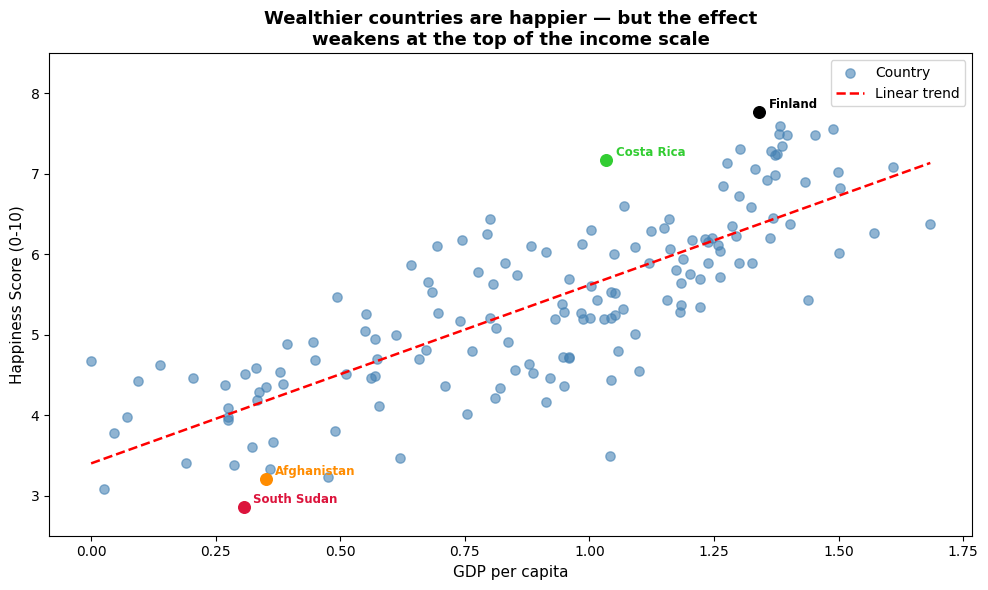

In [107]:
# GDP vs Happiness score
# Question: Does money buy happiness? And if yes or no, does it reflect across all the countries

fig, ax = plt.subplots(figsize=(10, 6))

# Represent countries in blue dots
ax.scatter(df["gdp"], df["score"],
           color="steelblue", alpha=0.6, s=45, label="Country")

coeffs = np.polyfit(df["gdp"], df["score"], deg=1)
x_line = np.linspace(df["gdp"].min(), df["gdp"].max(), 200)
y_line = np.polyval(coeffs, x_line)
ax.plot(x_line, y_line, color="red", linewidth=1.8,
        linestyle="--", label="Linear trend")

# Annotate some countries
highlight = {
    "Finland":     "black",
    "South Sudan": "crimson",
    "Afghanistan": "darkorange",
    "Costa Rica":  "limegreen",
}
for country, color in highlight.items():
    row = df[df["country"] == country].iloc[0]
    ax.scatter(row["gdp"], row["score"], color=color, s=70, zorder=5)
    ax.annotate(country,
                xy=(row["gdp"], row["score"]),
                xytext=(7, 3), textcoords="offset points",
                fontsize=8.5, color=color, fontweight="bold")

# Give figure title and label axes
ax.set_title("Wealthier countries are happier — but the effect\n"
             "weakens at the top of the income scale",
             fontsize=13, fontweight="bold")
ax.set_xlabel("GDP per capita", fontsize=11)
ax.set_ylabel("Happiness Score (0-10)", fontsize=11)
ax.legend()
ax.set_ylim(2.5, 8.5) # Truncate y-axis starting from 2.5

plt.tight_layout()
plt.savefig("fig1_gdp_score.png", dpi=150)
plt.show()

I choose a scatter plot as most appropriate to represent the relationship between two continuous variables (Happiness score and GDP per capita) across 156 individual observations. Other charts like a bar chart will lead to loss of some countries position while a line chart would imply a time order that does not exist.
The scatter plot shows a positive correlation between GDP per capita and happiness score, althouugh the trend flattens at highest GDP (Singapore and Qatar) where countries with highest GDP are not necessarily the most happiest country.

The y-axis was truncated because the lowest Happiness score is 2.8, as it cannot have a negative value. Thus, y-axis started at 2.5.